# <font color='green'> DebyeCalculator added utilities : examples</font>

## In this notebook, we will demonstrate how to use the added utilities *(from utilsDC in pyNanoMatBuilder*) to ease Debye Calculator's use. 

### Added utilities :
- plotting I(q),F(q),S(q) and G(r) of multiples nanoparticles
- create multiple csv files containing scattering data calculated from xyz/cif files/ASE objects

In [1]:
import debyecalculator
print(debyecalculator.__file__)


/home/sara/Python3/Debye_calc/lib/python3.11/site-packages/debyecalculator/__init__.py


In [2]:
import sys
print(sys.executable)# Afficher les fichiers ajoutés au bouton de téléchargement


/home/sara/Python3/Debye_calc/bin/python


In [3]:
#imports
import os
import pyNanoMatBuilder
from debyecalculator import DebyeCalculator
import pyNanoMatBuilder.utilsDC as pyNMBuDC


print(os.getcwd()) #path

/home/sara/pyNanoMatBuilder


## 1. Plotting loglog(I(q), S(q), F(q), G(r)) using an atomic structure source in XYZ/CIF format, ASE Atoms object, or as a tuple of (atomic_identities, atomic_positions).

### I=f(q) using cif file

/tmp/ipykernel_10757/3012628611.py:9: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


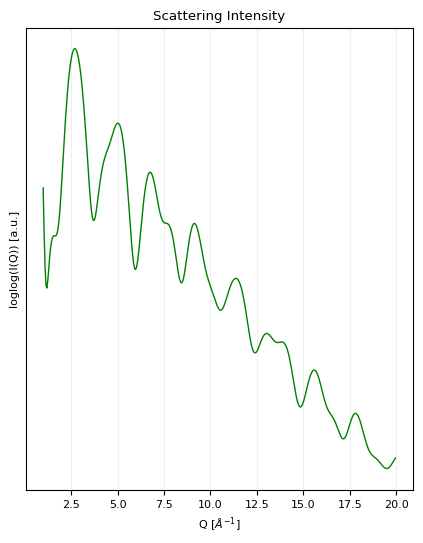

In [4]:
from debyecalculator import DebyeCalculator

path='/home/sara/pyNanoMatBuilder/coords/AuParallepiped.cif'

#path = os.path.join(
radii = [5.0]

# path_to_xyz_file = "debyecalculator/data/AntiFluorite_Co2O.cif"
calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)
q, iq = calc.iq(path, radii)

#q, iq = calc.iq('/home/sara/pyNanoMatBuilder/coords/cubo.xyz')
pyNMBuDC.plot_loglogiq(calc, q, iq, figsize=(5,6),color='green')

### I=f(q) using xyz file

coords/cubo.xyz


/tmp/ipykernel_183974/2912282340.py:4: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


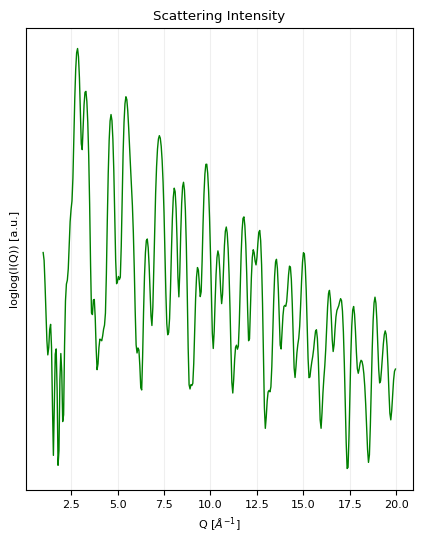

In [5]:

path = os.path.join("coords", "cubo.xyz")
print(path)  

calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)
q, iq = calc.iq(path)

#q, iq = calc.iq('/home/sara/pyNanoMatBuilder/coords/cubo.xyz')
pyNMBuDC.plot_loglogiq(calc, q, iq, figsize=(5,6),color='green')

### Plotting S=f(q)

coords/SphericalAuNP.xyz


/tmp/ipykernel_183974/1000982283.py:4: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


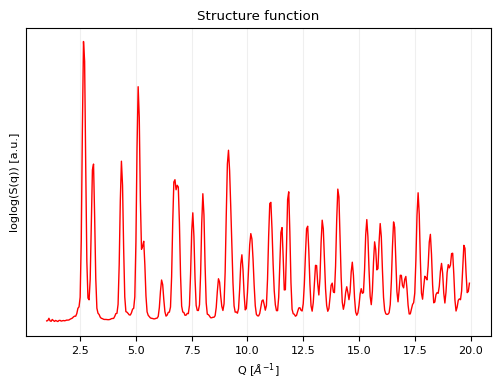

In [6]:
path = os.path.join("coords", 'SphericalAuNP.xyz')
print(path)  
     
calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)
q, sq = calc.sq(path)
 

pyNMBuDC.plot_sq(calc, q, sq, figsize=(6,4),color='red')

### Plotting F=f(q)

coords/RuWire.xyz


/tmp/ipykernel_183974/1404364647.py:4: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


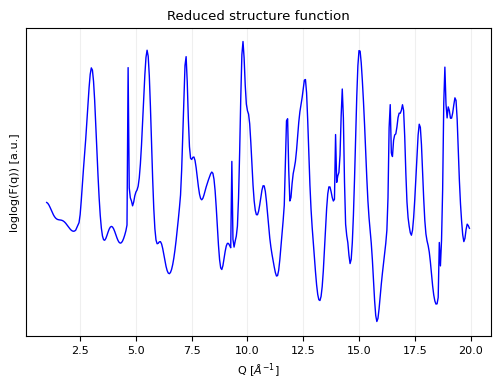

In [8]:
path = os.path.join("coords", "RuWire.xyz")
print(path)  

calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)
q, fq = calc.fq(path)


pyNMBuDC.plot_fq(calc, q, fq, figsize=(6,4),color='blue')

### Plotting G=f(r)

coords/EllipsoidalRuNP.xyz


/tmp/ipykernel_183974/2957674330.py:4: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


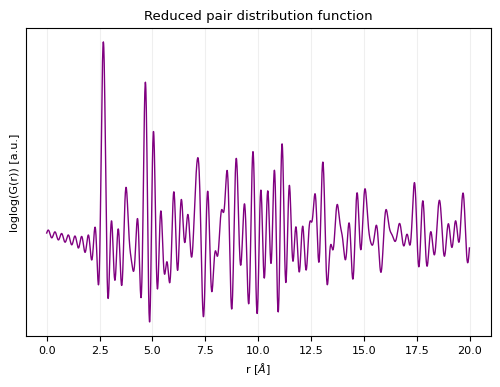

In [9]:
path = os.path.join("coords", "EllipsoidalRuNP.xyz")
print(path)  

calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)
r, gr = calc.gr(path)

# Maintenant pour plot 
pyNMBuDC.plot_gr(calc, r, gr, figsize=(6,4),color='purple')


## 2. Create multiple csv files containing scattering data calculated from atomic structure source in XYZ/CIF format, ASE Atoms object, or as a tuple of (atomic_identities, atomic_positions).

The fuction `create_iqfiles_from_xyzfiles()`, as well as the fuctions for S(q),F(q) and G(r), takes as input:
- an instance of DebyeCalculator class
- path of the xyz/cif files
- path of the final csv files\
 <font color='green'> Note : the xyz files contain a dictionnary of meta data : composition, cristalline structure, shape, size.

In [5]:
path_of_coords=os.path.join("xyz_files_predef_wulff")
path_of_csvfiles=os.path.join("csv_files")


calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)
pyNMBuDC.create_iqfiles_from_xyzfiles(calc,path_of_coords,path_of_csvfiles)

/tmp/ipykernel_79621/3354287122.py:5: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


File format Error(not .xyz) : NaCl_fcc_trcube_0000001_0000000.cif
file used : NaCl_fcc_Oh_0000001_0000000.xyz
q 380 iq 380
New file created: csv_files/NaCl_fcc_Oh_0000001_0000000_DC_iq.csv
file used : Au_fcc_trcube_0000001_0000000.xyz
q 380 iq 380
New file created: csv_files/Au_fcc_trcube_0000001_0000000_DC_iq.csv
file used : Co_fcc_trcube_0000001_0000000.xyz
q 380 iq 380
New file created: csv_files/Co_fcc_trcube_0000001_0000000_DC_iq.csv
File format Error(not .xyz) : Co_hcp_hcpwire_0000001_0000000.cif
file used : Au_fcc_Oh_0000001_0000000.xyz
q 380 iq 380
New file created: csv_files/Au_fcc_Oh_0000001_0000000_DC_iq.csv
File format Error(not .xyz) : Co_fcc_trOh_0000001_0000000.cif
File format Error(not .xyz) : Fe_bcc_cube_0000001_0000000.cif
File format Error(not .xyz) : Co_fcc_trcube_0000001_0000000.cif
File format Error(not .xyz) : Co_hcp_hcpsph2_0000001_0000000.cif
file used : Co_fcc_trOh_0000001_0000000.xyz
q 380 iq 380
New file created: csv_files/Co_fcc_trOh_0000001_0000000_DC_iq.c

### CSV files containing (q,I)

In [12]:
path_of_coords=os.path.join("coords_test_debye")
print(path_of_coords)  

path_of_csvfiles=os.path.join("csv_files")
print(path_of_csvfiles)  

calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)

pyNMBuDC.create_iqfiles_from_xyzfiles(calc,path_of_coords,path_of_csvfiles)

coords_test_debye
csv_files
File format Error(not .xyz) : .ipynb_checkpoints
file used : Au_bcc_cube_10.xyz
q 380 iq 380
New file created: csv_files/Au_bcc_cube_10_DC_iq.csv
file used : Au_bcc_cube_30.xyz


/tmp/ipykernel_173127/3233429446.py:7: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


q 380 iq 380
New file created: csv_files/Au_bcc_cube_30_DC_iq.csv
file used : Au_fcc_cube_10.xyz
q 380 iq 380
New file created: csv_files/Au_fcc_cube_10_DC_iq.csv
file used : Au_fcc_cube_30.xyz
q 380 iq 380
New file created: csv_files/Au_fcc_cube_30_DC_iq.csv
file used : Au_fcc_cube_20.xyz
q 380 iq 380
New file created: csv_files/Au_fcc_cube_20_DC_iq.csv
file used : Au_bcc_cube_20.xyz
q 380 iq 380
New file created: csv_files/Au_bcc_cube_20_DC_iq.csv


### CSV files containing (q,S)

In [5]:
path_of_coords=os.path.join('coord_cif_xyz')     
path_of_csvfiles=os.path.join("csv_files")
                
calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)   
radii=[5.0]
pyNMBuDC.create_sqfiles_from_xyzfiles(calc,path_of_coords,path_of_csvfiles,radii)

/tmp/ipykernel_177601/175763316.py:4: UserWarning: Warning: Your system might have a CUDA-enabled GPU, but CUDA is not available. Computations will run on the CPU instead. For optimal performance, please install Pytorch with CUDA support. If you do not have a CUDA-enabled GPU, you can surpress this warning by specifying the 'device' argument as 'cpu'
  calc = DebyeCalculator(qmin=1.0, qmax=20.0, qstep=0.05, qdamp=0.0, biso=0.0)


file used : SphericalTiO2rNP.cif
q 380 sq 380
New file created: csv_files/SphericalTiO2rNP_DC_sq.csv
file used : RuWire.cif
q 380 sq 380
New file created: csv_files/RuWire_DC_sq.csv
file used : Au_bcc_cube_30.xyz
q 380 sq 380
New file created: csv_files/Au_bcc_cube_30_DC_sq.csv
file used : EllipsoidalRuNP.cif
q 380 sq 380
New file created: csv_files/EllipsoidalRuNP_DC_sq.csv


### CSV files containing (q,F)

In [4]:
pyNMBuDC.create_fqfiles_from_xyzfiles(calc,path_of_coords,path_of_csvfiles)

File format Error(not .xyz) : .ipynb_checkpoints
file used : Au_bcc_cube_10.xyz
q 380 fq 380
New file created: csv_files/Au_bcc_cube_10_DC_fq.csv
file used : Au_bcc_cube_30.xyz
q 380 fq 380
New file created: csv_files/Au_bcc_cube_30_DC_fq.csv
file used : Au_fcc_cube_10.xyz
q 380 fq 380
New file created: csv_files/Au_fcc_cube_10_DC_fq.csv
file used : Au_fcc_cube_30.xyz
q 380 fq 380
New file created: csv_files/Au_fcc_cube_30_DC_fq.csv
file used : Au_fcc_cube_20.xyz
q 380 fq 380
New file created: csv_files/Au_fcc_cube_20_DC_fq.csv
file used : Au_bcc_cube_20.xyz
q 380 fq 380
New file created: csv_files/Au_bcc_cube_20_DC_fq.csv


### CSV files containing (r,G)

In [5]:
pyNMBuDC.create_grfiles_from_xyzfiles(calc,path_of_coords,path_of_csvfiles)

File format Error(not .xyz) : .ipynb_checkpoints
file used : Au_bcc_cube_10.xyz
r 2000 gr 2000
New file created: csv_files/Au_bcc_cube_10_DC_gr.csv
file used : Au_bcc_cube_30.xyz
r 2000 gr 2000
New file created: csv_files/Au_bcc_cube_30_DC_gr.csv
file used : Au_fcc_cube_10.xyz
r 2000 gr 2000
New file created: csv_files/Au_fcc_cube_10_DC_gr.csv
file used : Au_fcc_cube_30.xyz
r 2000 gr 2000
New file created: csv_files/Au_fcc_cube_30_DC_gr.csv
file used : Au_fcc_cube_20.xyz
r 2000 gr 2000
New file created: csv_files/Au_fcc_cube_20_DC_gr.csv
file used : Au_bcc_cube_20.xyz
r 2000 gr 2000
New file created: csv_files/Au_bcc_cube_20_DC_gr.csv


## à ajouter :
- pouvoir tracer plusieurs graph à la fois
- pour la fonction qui trace les fichiers : ajouter plusieurs entrées possibles : objet ASE, chemin, fichier
- attention : fichier cif ne fonctionne pas !! manque "radii"
- enlever " .ipynb_checkpoints" quand on vérifie le type de fichier
- filtre : attention je l'avais ajouté dans debye calculator (parse elements) mais à ajouter ailleurs